### Description:
    This script implements Active Learning using the Query by Committee (QBC) strategy.
    A committee of models is trained on different bootstrap samples of the labeled data.
    For the unlabeled pool, we measure the committee's disagreement via vote entropy and select
    the most uncertain samples for labeling. The model's performance on the validation set is
    evaluated (using majority vote over the committee), and results are plotted over iterations.

In [1]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [2]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from datasets import load_dataset
from torch.utils.data import DataLoader, Subset
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
import math

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [13]:
model_name = "distilbert-base-uncased"
num_labels = 2

def create_model():
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    return model

tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
train_dataset = load_dataset("glue", "sst2", split="train")
val_dataset = load_dataset("glue", "sst2", split="validation")

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

In [6]:
def collate_fn(batch):
    texts = [item["sentence"] for item in batch]
    labels = [item["label"] for item in batch]
    tokenized_inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    tokenized_inputs["labels"] = torch.tensor(labels)
    return tokenized_inputs


### Active Learning:

In [7]:
initial_label_size = 50
acquisition_size = 50
max_iterations = 10
committee_size = 3  # Number of models in the committee

In [8]:
all_indices = list(range(len(train_dataset)))
random.shuffle(all_indices)

labeled_indices = all_indices[:initial_label_size]
unlabeled_indices = all_indices[initial_label_size:]

In [9]:
labeled_sizes = []
val_accuracies = []

#### Active Learning Loop:

In [10]:
for iteration in range(max_iterations):
    print(f"\n=== Active Learning Iteration {iteration+1} ===")

    # --- Committee Training ---
    committee = []
    for i in range(committee_size):

        model = create_model().to(device)
        optimizer = AdamW(model.parameters(), lr=2e-5)

        bootstrap_indices = np.random.choice(labeled_indices, size=len(labeled_indices), replace=True)
        bootstrap_subset = Subset(train_dataset, bootstrap_indices)
        bootstrap_loader = DataLoader(bootstrap_subset, batch_size=16, shuffle=True, collate_fn=collate_fn)

        model.train()
        epochs = 2
        for epoch in range(epochs):
            epoch_loss = 0
            for batch in bootstrap_loader:
                optimizer.zero_grad()
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            print(f"Committee Member {i+1}, Epoch {epoch+1} Loss: {epoch_loss/len(bootstrap_loader):.4f}")

        committee.append(model)

    # --- Evaluation on the Validation Set using Committee Majority Vote ---
    val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
    all_votes = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            batch_votes = []

            for model in committee:
                model.eval()
                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=-1)
                batch_votes.append(preds.cpu().numpy())

            batch_votes = np.array(batch_votes).T  # shape: (batch_size, committee_size)

            for votes in batch_votes:
                vote_counts = Counter(votes)
                majority_vote = vote_counts.most_common(1)[0][0]
                all_votes.append(majority_vote)
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_votes) == np.array(all_labels))
    print(f"Validation Accuracy (Committee Majority Vote): {accuracy*100:.2f}%")
    labeled_sizes.append(len(labeled_indices))
    val_accuracies.append(accuracy)

    # --- Acquisition: Query by Committee using Vote Entropy ---
    if len(unlabeled_indices) == 0:
        break

    unlabeled_subset = Subset(train_dataset, unlabeled_indices)
    unlabeled_loader = DataLoader(unlabeled_subset, batch_size=32, collate_fn=collate_fn)

    vote_entropy_list = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(unlabeled_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            committee_preds = []
            for model in committee:
                model.eval()
                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=-1)
                committee_preds.append(preds.cpu().numpy())

            committee_preds = np.array(committee_preds)  # shape: (committee_size, batch_size)

            batch_size = committee_preds.shape[1]
            for j in range(batch_size):
                votes = committee_preds[:, j]
                vote_counts = Counter(votes)

                entropy = 0.0
                for cls in range(num_labels):
                    p = vote_counts.get(cls, 0) / committee_size
                    if p > 0:
                        entropy -= p * math.log(p)

                global_index = unlabeled_indices[batch_idx * 32 + j]
                vote_entropy_list.append((global_index, entropy))

    vote_entropy_list.sort(key=lambda x: x[1], reverse=True)

    selected_samples = [idx for idx, ent in vote_entropy_list[:acquisition_size]]

    labeled_indices.extend(selected_samples)
    unlabeled_indices = list(set(unlabeled_indices) - set(selected_samples))

    print(f"Total labeled samples after acquisition: {len(labeled_indices)}")



=== Active Learning Iteration 1 ===


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Committee Member 1, Epoch 1 Loss: 0.7144


...

Total labeled samples after acquisition: 500

=== Active Learning Iteration 10 ===
Committee Member 1, Epoch 1 Loss: 0.6711


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Committee Member 1, Epoch 2 Loss: 0.4114
Committee Member 2, Epoch 1 Loss: 0.6588
Committee Member 2, Epoch 2 Loss: 0.3773


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Committee Member 3, Epoch 1 Loss: 0.6749
Committee Member 3, Epoch 2 Loss: 0.4626
Validation Accuracy (Committee Majority Vote): 83.37%
Total labeled samples after acquisition: 550


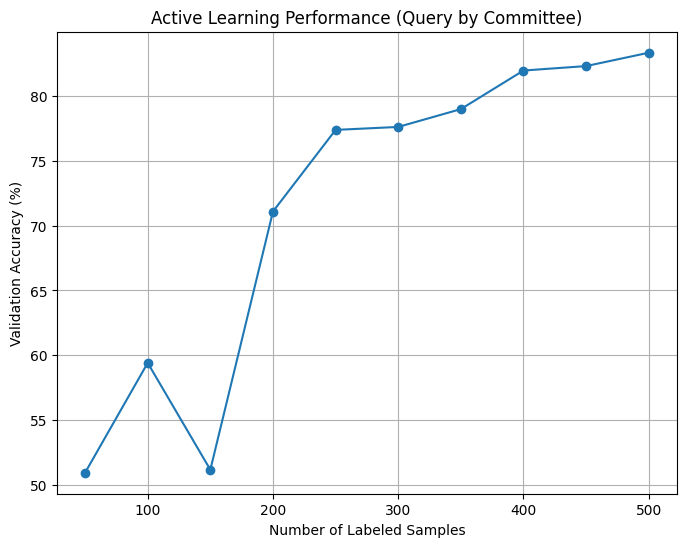

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(labeled_sizes, [acc * 100 for acc in val_accuracies], marker='o', linestyle='-')
plt.xlabel("Number of Labeled Samples")
plt.ylabel("Validation Accuracy (%)")
plt.title("Active Learning Performance (Query by Committee)")
plt.grid(True)
plt.show()